# Support Vector Machine_pipeline(Scale+train+tune) #

In [68]:
#import libraries:
import pandas as pd

In [69]:
# Read .csv file:
dataset = pd.read_csv('insurance_pre.csv')
dataset.head()

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520


In [70]:
# Check the dataset:
dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
charges     0
dtype: int64

In [71]:
dataset.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges'], dtype='object')

In [72]:
dataset.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
charges     float64
dtype: object

In [73]:
# convert the categorical columns:
dataset = pd.get_dummies(dataset,drop_first=True,dtype=int)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes
0,19,27.900,0,16884.92400,0,1
1,18,33.770,1,1725.55230,1,0
2,28,33.000,3,4449.46200,1,0
3,33,22.705,0,21984.47061,1,0
4,32,28.880,0,3866.85520,1,0


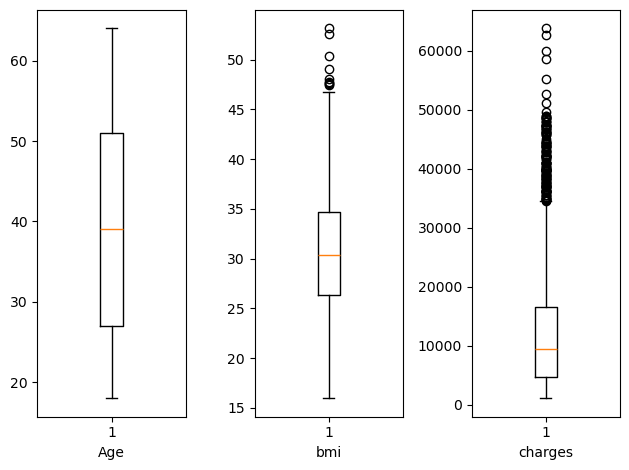

In [74]:
# Pre-processing the data:
#check the outlier:
import matplotlib.pyplot as plt
# plt.boxplot(dataset[['age','bmi','charges']])
# plt.show()
# plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.boxplot(dataset['age'])
plt.xlabel('Age')

plt.subplot(1,3,2)
plt.boxplot(dataset['bmi'])
plt.xlabel('bmi')

plt.subplot(1,3,3)
plt.boxplot(dataset['charges'])
plt.xlabel('charges')

plt.tight_layout()
plt.show()

In [75]:
# bmi has outlier:	In insurance charges dataset, high BMI or age can be real, so won’t touch it.

In [76]:
#IQR Capping:
Q1 = dataset['bmi'].quantile(0.25)
Q3 = dataset['bmi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
higher = Q3 + 1.5 * IQR

dataset['bmi'] = dataset['bmi'].clip(lower,higher)
dataset['bmi']

0       27.900
1       33.770
2       33.000
3       22.705
4       28.880
         ...  
1333    30.970
1334    31.920
1335    36.850
1336    25.800
1337    29.070
Name: bmi, Length: 1338, dtype: float64

Text(0.5, 0, 'bmi')

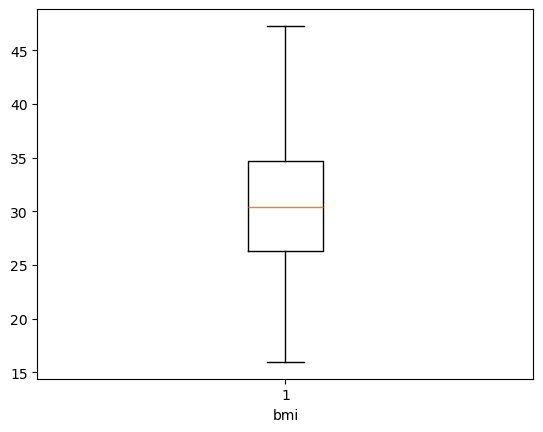

In [77]:
plt.boxplot(dataset['bmi'])
plt.xlabel('bmi')

Text(0.5, 0, 'charges')

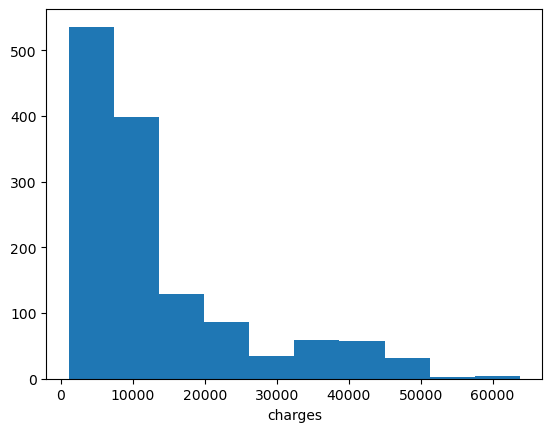

In [78]:
# Before outlier handling:
plt.hist(dataset['charges'])
plt.xlabel('charges')

In [79]:
# handling outlier in charges columns:
# Highly right-skewed
# High values are real & important (smokers, older people)
# These “outliers” carry business meaning
# so, i am go for Log transformation:
import numpy as np
dataset['charges_log'] = np.log1p(dataset['charges'])
dataset['charges_log'] 

0        9.734236
1        7.453882
2        8.400763
3        9.998137
4        8.260455
          ...    
1333     9.268755
1334     7.699381
1335     7.396847
1336     7.605365
1337    10.279948
Name: charges_log, Length: 1338, dtype: float64

Text(0.5, 0, 'charges_log')

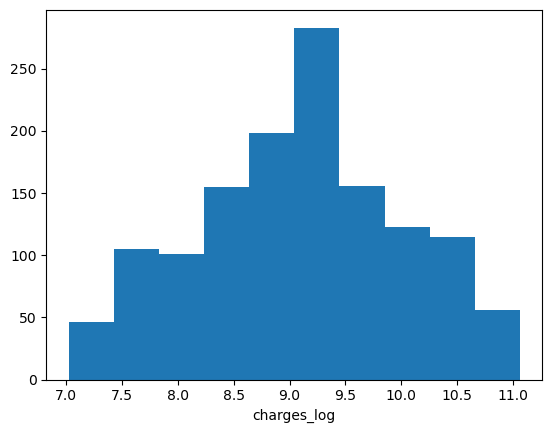

In [80]:
# After outlier handling:
plt.hist(dataset['charges_log'])
plt.xlabel('charges_log')

In [81]:
dataset.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'charges_log'],
      dtype='object')

In [82]:
# Split Input and output columns:
independent = dataset[['age', 'bmi', 'children', 'sex_male', 'smoker_yes']]
dependent = dataset['charges_log']

In [83]:
#Split Train and test:
from sklearn.model_selection import train_test_split , GridSearchCV
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size = 0.3,random_state = 0)

In [84]:
# To avoid scaling tuning manually: i am go for pipeline: it will take care automatecally:
# import Pipeline frome pipeline
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler 
from sklearn.svm import SVR

pipe = Pipeline([('scale',StandardScaler()),
          ('model',SVR())])

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__gamma': ['scale', 0.01, 0.1, 1],
    'model__kernel': ['rbf']
}
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)


In [85]:
grid.fit(x_train, y_train)
print("Best parameters:", grid.best_params_)
print("Best CV R² score:", grid.best_score_)


Best parameters: {'model__C': 100, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV R² score: 0.8187686155501129


In [86]:

best_model = grid.best_estimator_

# r2_train = best_model.score(x_train, y_train)
y_train_pred = best_model.predict(x_train)
train_r2_score = r2_score(y_train, y_train_pred)

# r2_test = best_model.score(x_test, y_test)
y_test_pred = best_model.predict(x_test)
test_r2_score = r2_score(y_test, y_test_pred)


NameError: name 'r2_score' is not defined

In [ ]:
print(f"Train R²: {r2_train}")
print(f"Test R²: {r2_test}")

In [ ]:
y_pred_log = best_model.predict(x_test)
y_pred = np.expm1(y_pred_log)

In [ ]:


# Optional: check actual vs predicted
plt.scatter(np.expm1(y_test), y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [ ]:
plt.scatter(np.expm1(y_test), y_pred)
plt.plot([0, max(np.expm1(y_test))], [0, max(np.expm1(y_test))], color='red', linestyle='--')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert predictions back to original scale
y_pred = np.expm1(best_model.predict(x_test))
y_actual = np.expm1(y_test)

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_actual, y_pred, color='blue', label='Predicted vs Actual')

# Perfect prediction line
max_val = max(max(y_actual), max(y_pred))
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Annotate points: overprediction and underprediction
for i in range(len(y_actual)):
    if y_pred[i] > y_actual.iloc[i]*1.2:   # 20% more → overpredicted
        plt.scatter(y_actual.iloc[i], y_pred[i], color='orange', s=60)
    elif y_pred[i] < y_actual.iloc[i]*0.8: # 20% less → underpredicted
        plt.scatter(y_actual.iloc[i], y_pred[i], color='green', s=60)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges with Over/Under Predictions")
plt.legend()
plt.show()
